# Phase 3 — Exploratory Data Analysis
Home Credit Default Risk Project

In [1]:
import sys
sys.path.append("../src")

from eda_utils import (
    get_column_lists,
    missing_values,
    bad_rate_summary,
    skewness_report,
    outlier_check,
    check_overlap,
    sentinel_bad_rate,
    coverage_bad_rate,
    categorical_analysis,
    variance_check,
)


In [2]:
import duckdb
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path


pd.set_option("display.max_columns", None)
pd.set_option("display.float_format", lambda x: f"{x:,.3f}")
sns.set_theme(style="whitegrid")

RAW       = Path("../data/raw")
PROCESSED = Path("../data/processed")

con = duckdb.connect()

TABLES = [
    "application_train", "application_test",
    "bureau", "bureau_balance",
    "previous_application", "POS_CASH_balance",
    "installments_payments", "credit_card_balance",
]
for t in TABLES:
    con.execute(f"""
        CREATE OR REPLACE VIEW {t} AS
        SELECT * FROM '{(PROCESSED / f"{t}.parquet").as_posix()}'
    """)

col_desc = pd.read_csv(RAW / "HomeCredit_columns_description.csv",
                       encoding="latin-1", index_col=0)

print("Views:", con.execute("SHOW TABLES").df()["name"].tolist())

Views: ['POS_CASH_balance', 'application_test', 'application_train', 'bureau', 'bureau_balance', 'credit_card_balance', 'installments_payments', 'previous_application']


## Step 1 — Structural Sanity Checks

In [3]:
# Load train and test
df_train = con.execute("SELECT * FROM application_train").df()
df_test  = con.execute("SELECT * FROM application_test").df()

# 1a — Shapes
print(f"Train shape: {df_train.shape}")
print(f"Test shape:  {df_test.shape}")

Train shape: (307511, 122)
Test shape:  (48744, 121)


In [4]:
# 1b — TARGET exists in train but not test
target_columns = df_train.columns
test_columns   = df_test.columns

if "TARGET" in target_columns:
    print("✅ Train df has the TARGET column")
else:
    print("⚠️  Train df does NOT have the TARGET column")

if "TARGET" not in test_columns:
    print("✅ Test df does NOT have the TARGET column — correct")
else:
    print("⚠️  Test df has the TARGET column — investigate")

✅ Train df has the TARGET column
✅ Test df does NOT have the TARGET column — correct


In [5]:
# 1c — SK_ID_CURR uniqueness
if df_train["SK_ID_CURR"].nunique() == len(df_train["SK_ID_CURR"]):
    print("✅ No duplicate SK_ID_CURR in Train df")
else:
    print("⚠️  Duplicate SK_ID_CURR found in Train df")

if df_test["SK_ID_CURR"].nunique() == len(df_test["SK_ID_CURR"]):
    print("✅ No duplicate SK_ID_CURR in Test df")
else:
    print("⚠️  Duplicate SK_ID_CURR found in Test df")

✅ No duplicate SK_ID_CURR in Train df
✅ No duplicate SK_ID_CURR in Test df


In [6]:
# 1d — Train/test overlap check (uses check_overlap from eda_utils)
check_overlap(df_train, df_test, "SK_ID_CURR")

✅ No overlap found in 'SK_ID_CURR' between the two DataFrames


In [7]:
# 1e — Build reusable column lists (uses get_column_lists from eda_utils)
numeric_data, categorical_data, binary_data = get_column_lists(df_train)

print(f"Numeric:     {len(numeric_data)} columns")
print(f"Categorical: {len(categorical_data)} columns")
print(f"Binary FLAG: {len(binary_data)} columns")

Numeric:     80 columns
Categorical: 12 columns
Binary FLAG: 28 columns


## Step 2 — Target / Bad-Rate Analysis

In [8]:
# 2a — Credit risk summary (uses bad_rate_summary from eda_utils)
bad_rate_summary(df_train)

--- Credit Risk Summary ---
Total records:     307,511
Population PD:     8.07%
Total bads:        24,825
Total goods:       282,686
Good:Bad ratio:    11.4:1


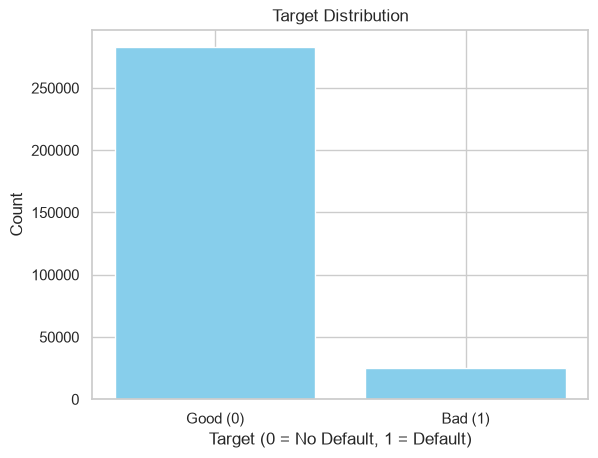

In [9]:
# 2b — Target distribution plot
counts = df_train["TARGET"].value_counts()

plt.bar(counts.index, counts.values, color="skyblue")
plt.xlabel("Target (0 = No Default, 1 = Default)")
plt.ylabel("Count")
plt.title("Target Distribution")
plt.xticks([0, 1], ["Good (0)", "Bad (1)"])
plt.show()

## Step 3 — Feature Typing, Cardinality & Sentinel Codes

In [10]:
# 3a — Categorical cardinality and value distributions
# (uses categorical_analysis from eda_utils for the summary table)
categorical_analysis(df_train, categorical_data)


══════════════════════════════════════════════════════════════════════
  CODE_GENDER
  Unique: 3   Missing: 0.00%
══════════════════════════════════════════════════════════════════════
              Count  Pct %  Bad Rate  vs Pop
CODE_GENDER                                 
M            105059 34.160    10.140   2.070
F            202448 65.830     7.000  -1.070
XNA               4  0.000     0.000  -8.070

  Population bad rate : 8.07%
  Rare categories (<5%): XNA

══════════════════════════════════════════════════════════════════════
  NAME_TYPE_SUITE
  Unique: 7   Missing: 0.42%
══════════════════════════════════════════════════════════════════════
                  Count  Pct %  Bad Rate  vs Pop
NAME_TYPE_SUITE                                 
Other_B            1770  0.580     9.830   1.760
Other_A             866  0.280     8.780   0.700
Group of people     271  0.090     8.490   0.410
Unaccompanied    248526 81.160     8.180   0.110
Spouse, partner   11370  3.710     7.870  -0.

In [11]:
# 3b — Detailed value counts per categorical (sentinel hunting)
for i in categorical_data:
    if i in df_train.columns:
        print(f"\n{'─'*50}")
        print(f"{i} — {df_train[i].nunique()} unique values")
        print(df_train[i].value_counts())


──────────────────────────────────────────────────
CODE_GENDER — 3 unique values
CODE_GENDER
F      202448
M      105059
XNA         4
Name: count, dtype: int64

──────────────────────────────────────────────────
NAME_TYPE_SUITE — 7 unique values
NAME_TYPE_SUITE
Unaccompanied      248526
Family              40149
Spouse, partner     11370
Children             3267
Other_B              1770
Other_A               866
Group of people       271
Name: count, dtype: int64

──────────────────────────────────────────────────
NAME_INCOME_TYPE — 8 unique values
NAME_INCOME_TYPE
Working                 158774
Commercial associate     71617
Pensioner                55362
State servant            21703
Unemployed                  22
Student                     18
Businessman                 10
Maternity leave              5
Name: count, dtype: int64

──────────────────────────────────────────────────
NAME_EDUCATION_TYPE — 5 unique values
NAME_EDUCATION_TYPE
Secondary / secondary special    218391


In [12]:
# 3c — Sentinel bad rate checks for categorical sentinels
# ORGANIZATION_TYPE XNA
sentinel_bad_rate(df_train, "ORGANIZATION_TYPE", lambda x: x == "XNA")

--- Sentinel Bad Rate Check: ORGANIZATION_TYPE ---
Sentinel population bad rate:     5.40%
Non-sentinel population bad rate: 8.66%
Overall population bad rate:      8.07%
Difference:                       -3.26pp


In [13]:
# NAME_TYPE_SUITE — Other_A and Other_B rare category check
for category in ["Other_A", "Other_B"]:
    bad_rate = df_train[df_train["NAME_TYPE_SUITE"] == category]["TARGET"].mean() * 100
    count    = (df_train["NAME_TYPE_SUITE"] == category).sum()
    pct      = count / len(df_train) * 100
    print(f"{category}: bad rate = {bad_rate:.2f}%, count = {count:,} ({pct:.2f}% of population)")

Other_A: bad rate = 8.78%, count = 866 (0.28% of population)
Other_B: bad rate = 9.83%, count = 1,770 (0.58% of population)


In [14]:
# 3d — Numeric skewness report (uses skewness_report from eda_utils)
skewness_report(df_train, numeric_data)

SK_ID_CURR: 🟢 Fairly symmetrical: -0.001
count   307,511.000
mean    278,180.519
std     102,790.175
min     100,002.000
25%     189,145.500
50%     278,202.000
75%     367,142.500
max     456,255.000
Name: SK_ID_CURR, dtype: float64

TARGET: 🔴 Highly skewed RIGHT: 3.078
count   307,511.000
mean          0.081
std           0.272
min           0.000
25%           0.000
50%           0.000
75%           0.000
max           1.000
Name: TARGET, dtype: float64

CNT_CHILDREN: 🔴 Highly skewed RIGHT: 1.975
count   307,511.000
mean          0.417
std           0.722
min           0.000
25%           0.000
50%           0.000
75%           1.000
max          19.000
Name: CNT_CHILDREN, dtype: float64

AMT_INCOME_TOTAL: 🔴 Highly skewed RIGHT: 391.560
count       307,511.000
mean        168,797.919
std         237,123.146
min          25,650.000
25%         112,500.000
50%         147,150.000
75%         202,500.000
max     117,000,000.000
Name: AMT_INCOME_TOTAL, dtype: float64

AMT_CREDIT: 🔴 High

In [15]:
# 3e — Outlier check (uses outlier_check from eda_utils)
outlier_check(df_train, numeric_data)

Column                                            Min             Max     99th Pct     Skew
──────────────────────────────────────────────────────────────────────────────────────────
SK_ID_CURR                                 100,002.00      456,255.00   452,712.90   -0.001
TARGET                                           0.00            1.00         1.00    3.078
CNT_CHILDREN                                     0.00           19.00         3.00    1.975
AMT_INCOME_TOTAL                            25,650.00  117,000,000.00   472,500.00  391.560
AMT_CREDIT                                  45,000.00    4,050,000.00 1,854,000.00    1.235
AMT_ANNUITY                                  1,615.50      258,025.50    70,006.50    1.580
AMT_GOODS_PRICE                             40,500.00    4,050,000.00 1,800,000.00    1.349
REGION_POPULATION_RELATIVE                       0.00            0.07         0.07    1.488
DAYS_BIRTH                                 -25,229.00       -7,489.00    -8,263.0

In [16]:
# 3f — CNT_CHILDREN vs CNT_FAM_MEMBERS consistency check
print(df_train["CNT_CHILDREN"].value_counts().sort_index())
print(df_train["CNT_FAM_MEMBERS"].value_counts().sort_index())

inconsistent = df_train[df_train["CNT_CHILDREN"] > df_train["CNT_FAM_MEMBERS"]]
print(f"Inconsistent rows (CNT_CHILDREN > CNT_FAM_MEMBERS): {len(inconsistent)}")

CNT_CHILDREN
0     215371
1      61119
2      26749
3       3717
4        429
5         84
6         21
7          7
8          2
9          2
10         2
11         1
12         2
14         3
19         2
Name: count, dtype: int64
CNT_FAM_MEMBERS
1.000      67847
2.000     158357
3.000      52601
4.000      24697
5.000       3478
6.000        408
7.000         81
8.000         20
9.000          6
10.000         3
11.000         1
12.000         2
13.000         1
14.000         2
15.000         1
16.000         2
20.000         2
Name: count, dtype: int64
Inconsistent rows (CNT_CHILDREN > CNT_FAM_MEMBERS): 0


In [17]:
# 3g — DAYS_EMPLOYED sentinel check (uses sentinel_bad_rate from eda_utils)
print(df_train["DAYS_EMPLOYED"].describe())
print(f"\nRows with sentinel (365243): {(df_train['DAYS_EMPLOYED'] == 365243).sum():,}")
print(f"% of data: {(df_train['DAYS_EMPLOYED'] == 365243).mean() * 100:.2f}%")

# Overlap with ORGANIZATION_TYPE XNA
overlap_sentinel = df_train[
    (df_train["DAYS_EMPLOYED"] == 365243) &
    (df_train["ORGANIZATION_TYPE"] == "XNA")
]["SK_ID_CURR"].nunique()
print(f"Overlap with ORGANIZATION_TYPE XNA: {overlap_sentinel:,}")

# Bad rate check
sentinel_bad_rate(df_train, "DAYS_EMPLOYED", lambda x: x == 365243)

count   307,511.000
mean     63,815.046
std     141,275.767
min     -17,912.000
25%      -2,760.000
50%      -1,213.000
75%        -289.000
max     365,243.000
Name: DAYS_EMPLOYED, dtype: float64

Rows with sentinel (365243): 55,374
% of data: 18.01%
Overlap with ORGANIZATION_TYPE XNA: 55,374
--- Sentinel Bad Rate Check: DAYS_EMPLOYED ---
Sentinel population bad rate:     5.40%
Non-sentinel population bad rate: 8.66%
Overall population bad rate:      8.07%
Difference:                       -3.26pp


In [18]:
# 3h — OWN_CAR_AGE sentinel check (uses sentinel_bad_rate from eda_utils)
print(df_train[df_train["OWN_CAR_AGE"] >= 60]["OWN_CAR_AGE"].value_counts().sort_index())
print(f"99th percentile: {df_train['OWN_CAR_AGE'].quantile(0.99)}")
print(f"Total rows with OWN_CAR_AGE = 64: {(df_train['OWN_CAR_AGE'] == 64).sum():,}")
print(f"% of cars with age recorded: {df_train['OWN_CAR_AGE'].notna().mean() * 100:.2f}%")

sentinel_bad_rate(df_train, "OWN_CAR_AGE", lambda x: x == 64)

OWN_CAR_AGE
63.000       2
64.000    2443
65.000     891
69.000       1
91.000       2
Name: count, dtype: int64
99th percentile: 64.0
Total rows with OWN_CAR_AGE = 64: 2,443
% of cars with age recorded: 34.01%
--- Sentinel Bad Rate Check: OWN_CAR_AGE ---
Sentinel population bad rate:     8.60%
Non-sentinel population bad rate: 7.21%
Overall population bad rate:      8.07%
Difference:                       +1.38pp


In [19]:
# 3i — Normalized features verification (EXT_SOURCE + building stats)
normalized_cols = [
    col for col in df_train.columns
    if (col in ["EXT_SOURCE_1", "EXT_SOURCE_2", "EXT_SOURCE_3"]
    or col.endswith("_AVG") or col.endswith("_MEDI")
    or col.endswith("_MODE"))
    and df_train[col].dtype in ["float64", "int64"]
]
for col in normalized_cols:
    print(f"{col:<40} min={df_train[col].min():.3f}  max={df_train[col].max():.3f}")

EXT_SOURCE_1                             min=0.015  max=0.963
EXT_SOURCE_2                             min=0.000  max=0.855
EXT_SOURCE_3                             min=0.001  max=0.896
APARTMENTS_AVG                           min=0.000  max=1.000
BASEMENTAREA_AVG                         min=0.000  max=1.000
YEARS_BEGINEXPLUATATION_AVG              min=0.000  max=1.000
YEARS_BUILD_AVG                          min=0.000  max=1.000
COMMONAREA_AVG                           min=0.000  max=1.000
ELEVATORS_AVG                            min=0.000  max=1.000
ENTRANCES_AVG                            min=0.000  max=1.000
FLOORSMAX_AVG                            min=0.000  max=1.000
FLOORSMIN_AVG                            min=0.000  max=1.000
LANDAREA_AVG                             min=0.000  max=1.000
LIVINGAPARTMENTS_AVG                     min=0.000  max=1.000
LIVINGAREA_AVG                           min=0.000  max=1.000
NONLIVINGAPARTMENTS_AVG                  min=0.000  max=1.000
NONLIVIN

## Step 4 — Missing Value Rate

In [20]:
# 4a — Missing value rate for application_train (uses missing_values from eda_utils)
print("=== application_train ===")
missing_values(df_train)

=== application_train ===
🟢 Percent missing:
COMMONAREA_MEDI            69.870
COMMONAREA_MODE            69.870
COMMONAREA_AVG             69.870
NONLIVINGAPARTMENTS_MODE   69.430
NONLIVINGAPARTMENTS_MEDI   69.430
                            ...  
DEF_60_CNT_SOCIAL_CIRCLE    0.330
DEF_30_CNT_SOCIAL_CIRCLE    0.330
OBS_30_CNT_SOCIAL_CIRCLE    0.330
EXT_SOURCE_2                0.210
AMT_GOODS_PRICE             0.090
Length: 64, dtype: float64

🟢 Number missing:
COMMONAREA_MEDI             214865
COMMONAREA_AVG              214865
COMMONAREA_MODE             214865
NONLIVINGAPARTMENTS_MODE    213514
NONLIVINGAPARTMENTS_AVG     213514
                             ...  
EXT_SOURCE_2                   660
AMT_GOODS_PRICE                278
AMT_ANNUITY                     12
CNT_FAM_MEMBERS                  2
DAYS_LAST_PHONE_CHANGE           1
Length: 67, dtype: int64


In [21]:
# 4b — EXT_SOURCE missing analysis
df_EXT_SOURCE_123 = df_train[["EXT_SOURCE_1", "EXT_SOURCE_2", "EXT_SOURCE_3"]]
missing_values(df_EXT_SOURCE_123)

🟢 Percent missing:
EXT_SOURCE_1   56.380
EXT_SOURCE_3   19.830
EXT_SOURCE_2    0.210
dtype: float64

🟢 Number missing:
EXT_SOURCE_1    173378
EXT_SOURCE_3     60965
EXT_SOURCE_2       660
dtype: int64


In [22]:
# 4c — EXT_SOURCE informative missingness check (uses sentinel_bad_rate from eda_utils)
for source in ["EXT_SOURCE_1", "EXT_SOURCE_2", "EXT_SOURCE_3"]:
    sentinel_bad_rate(df_train, source, lambda x: x.isna())
    print()

--- Sentinel Bad Rate Check: EXT_SOURCE_1 ---
Sentinel population bad rate:     8.52%
Non-sentinel population bad rate: 7.50%
Overall population bad rate:      8.07%
Difference:                       +1.02pp

--- Sentinel Bad Rate Check: EXT_SOURCE_2 ---
Sentinel population bad rate:     7.88%
Non-sentinel population bad rate: 8.07%
Overall population bad rate:      8.07%
Difference:                       -0.19pp

--- Sentinel Bad Rate Check: EXT_SOURCE_3 ---
Sentinel population bad rate:     9.31%
Non-sentinel population bad rate: 7.77%
Overall population bad rate:      8.07%
Difference:                       +1.55pp



## Bureau Table — Missing Value Rate

In [23]:
# Load bureau and run missing values
df_bureau = con.execute("SELECT * FROM bureau").df()
print(f"Bureau shape: {df_bureau.shape}")
missing_values(df_bureau)

Bureau shape: (1716428, 17)
🟢 Percent missing:
AMT_ANNUITY              71.470
AMT_CREDIT_MAX_OVERDUE   65.510
DAYS_ENDDATE_FACT        36.920
AMT_CREDIT_SUM_LIMIT     34.480
AMT_CREDIT_SUM_DEBT      15.010
DAYS_CREDIT_ENDDATE       6.150
dtype: float64

🟢 Number missing:
AMT_ANNUITY               1226791
AMT_CREDIT_MAX_OVERDUE    1124488
DAYS_ENDDATE_FACT          633653
AMT_CREDIT_SUM_LIMIT       591780
AMT_CREDIT_SUM_DEBT        257669
DAYS_CREDIT_ENDDATE        105553
AMT_CREDIT_SUM                 13
dtype: int64


In [24]:
# Bureau table contains records for all clients Home Credit has ever had data on, I need just the one from my Train dataset
df_bureau = con.execute("""
    SELECT * FROM bureau
    WHERE SK_ID_CURR in (SELECT SK_ID_CURR FROM application_train)
""").df()

print(f"Bureau shape: {df_bureau.shape}\n")
missing_values(df_bureau)
print(f"Unique applicants in bureau: {df_bureau['SK_ID_CURR'].nunique():,}\n")
print(f"Total train applicants:      {df_train['SK_ID_CURR'].nunique():,}\n")
coverage = df_bureau['SK_ID_CURR'].nunique() / df_train['SK_ID_CURR'].nunique() * 100
print(f"Coverage:                    {coverage:.1f}%\n")
print(f"\nRows per applicant:")
print(df_bureau.groupby('SK_ID_CURR').size().describe())

Bureau shape: (1465325, 17)

🟢 Percent missing:
AMT_ANNUITY              77.120
AMT_CREDIT_MAX_OVERDUE   64.730
DAYS_ENDDATE_FACT        37.170
AMT_CREDIT_SUM_LIMIT     33.420
AMT_CREDIT_SUM_DEBT      15.220
DAYS_CREDIT_ENDDATE       6.080
dtype: float64

🟢 Number missing:
AMT_ANNUITY               1130013
AMT_CREDIT_MAX_OVERDUE     948545
DAYS_ENDDATE_FACT          544673
AMT_CREDIT_SUM_LIMIT       489670
AMT_CREDIT_SUM_DEBT        223094
DAYS_CREDIT_ENDDATE         89098
AMT_CREDIT_SUM                  3
dtype: int64
Unique applicants in bureau: 263,491

Total train applicants:      307,511

Coverage:                    85.7%


Rows per applicant:
count   263,491.000
mean          5.561
std           4.378
min           1.000
25%           2.000
50%           4.000
75%           8.000
max         116.000
dtype: float64


In [25]:
coverage_bad_rate(df_train, df_bureau, "SK_ID_CURR")

--- Coverage Bad Rate Check: SK_ID_CURR ---
Applicants with records:    263,491 (85.7%)
Thin-file (no records):     44,020 (14.3%)
Bad rate — has records:     7.73%
Bad rate — thin file:       10.12%
Bad rate — population:      8.07%
Difference:                 +2.39pp


In [26]:
print(df_bureau.groupby("SK_ID_CURR").size().sort_values(ascending=False).head(10))

SK_ID_CURR
120860    116
169704     94
251643     61
295809     59
129843     58
177014     56
218175     55
280155     55
281455     54
430261     54
dtype: int64


In [27]:
# Creating the list of columns for 3 different type
numeric_bureau, categorical_bureau, binary_bureau = get_column_lists(df_bureau)

print(f"\nNumeric: {numeric_bureau}")
print(f"Numeric: {len(numeric_bureau)} columns")

print(f"\nCategorical: {categorical_bureau}")
print(f"Categorical: {len(categorical_bureau)} columns")

print(f"\nBinary: {binary_bureau}")
print(f"Binary: {len(binary_bureau)} columns")


Numeric: ['SK_ID_CURR', 'SK_ID_BUREAU', 'DAYS_CREDIT', 'CREDIT_DAY_OVERDUE', 'DAYS_CREDIT_ENDDATE', 'DAYS_ENDDATE_FACT', 'AMT_CREDIT_MAX_OVERDUE', 'CNT_CREDIT_PROLONG', 'AMT_CREDIT_SUM', 'AMT_CREDIT_SUM_DEBT', 'AMT_CREDIT_SUM_LIMIT', 'AMT_CREDIT_SUM_OVERDUE', 'DAYS_CREDIT_UPDATE', 'AMT_ANNUITY']
Numeric: 14 columns

Categorical: ['CREDIT_ACTIVE', 'CREDIT_CURRENCY', 'CREDIT_TYPE']
Categorical: 3 columns

Binary: []
Binary: 0 columns


In [28]:
categorical_analysis(df_bureau, categorical_bureau)



══════════════════════════════════════════════════════════════════════
  CREDIT_ACTIVE
  Unique: 4   Missing: 0.00%
══════════════════════════════════════════════════════════════════════
                Count  Pct %
CREDIT_ACTIVE               
Closed         917733 62.630
Active         541919 36.980
Sold             5653  0.390
Bad debt           20  0.000
  Rare categories (<5%): Sold, Bad debt

══════════════════════════════════════════════════════════════════════
  CREDIT_CURRENCY
  Unique: 4   Missing: 0.00%
══════════════════════════════════════════════════════════════════════
                   Count  Pct %
CREDIT_CURRENCY                
currency 1       1464094 99.920
currency 2          1072  0.070
currency 3           150  0.010
currency 4             9  0.000
  Rare categories (<5%): currency 2, currency 3, currency 4

══════════════════════════════════════════════════════════════════════
  CREDIT_TYPE
  Unique: 15   Missing: 0.00%
════════════════════════════════════════

In [29]:
skewness_report(df_bureau, numeric_bureau)

SK_ID_CURR: 🟢 Fairly symmetrical: -0.000
count   1,465,325.000
mean      278,328.538
std       102,919.334
min       100,002.000
25%       188,970.000
50%       278,289.000
75%       367,494.000
max       456,255.000
Name: SK_ID_CURR, dtype: float64

SK_ID_BUREAU: 🟢 Fairly symmetrical: 0.100
count   1,465,325.000
mean    5,890,327.739
std       537,827.071
min     5,000,000.000
25%     5,416,944.000
50%     5,856,021.000
75%     6,363,543.000
max     6,843,457.000
Name: SK_ID_BUREAU, dtype: float64

DAYS_CREDIT: 🟡 Moderately skewed LEFT: -0.578
count   1,465,325.000
mean       -1,143.600
std           800.020
min        -2,922.000
25%        -1,671.000
50%          -985.000
75%          -470.000
max             0.000
Name: DAYS_CREDIT, dtype: float64

CREDIT_DAY_OVERDUE: 🔴 Highly skewed RIGHT: 53.571
count   1,465,325.000
mean            0.889
std            38.247
min             0.000
25%             0.000
50%             0.000
75%             0.000
max         2,792.000
Name: CREDIT

In [30]:
# AMT_CREDIT_SUM_DEBT min = -4,705,600 -> Negative debt is impossible in theory
print(f"Negative debt rows: {(df_bureau['AMT_CREDIT_SUM_DEBT'] < 0).sum():,}")

# AMT_CREDIT_SUM_LIMIT min = -586,406 Same issue — negative credit limit is impossible.
print(f"Negative limit rows: {(df_bureau['AMT_CREDIT_SUM_LIMIT'] <0 ).sum():,}")

# DAYS_CREDIT_UPDATE max = 372 Positive value means the update happened after the application date — suspicious.
print(f"Rows with future update: {(df_bureau['DAYS_CREDIT_UPDATE'] > 0).sum():,}")

print(f"Ever overdue: {(df_bureau['CREDIT_DAY_OVERDUE'] > 0).sum():,}")
print(f"Ever prolonged: {(df_bureau['CNT_CREDIT_PROLONG'] > 0).sum():,}")

Negative debt rows: 8,418
Negative limit rows: 351
Rows with future update: 17
Ever overdue: 3,706
Ever prolonged: 8,820


In [31]:
# CREDIT_DAY_OVERDUE — 3,706 ever overdue Only 0.25% of bureau credits are currently overdue — but these are extremely high-risk signals.
bureau_with_target = df_bureau.merge(
    df_train[["SK_ID_CURR", "TARGET"]],
    on="SK_ID_CURR",
    how="left"
)

overdue_bad = bureau_with_target[bureau_with_target["CREDIT_DAY_OVERDUE"] > 0]["TARGET"].mean() * 100
non_overdue_bad = bureau_with_target[bureau_with_target["CREDIT_DAY_OVERDUE"] == 0]["TARGET"].mean() * 100

print(f"Bad rate — currently overdue:     {overdue_bad:.2f}%")
print(f"Bad rate — not overdue:           {non_overdue_bad:.2f}%")

Bad rate — currently overdue:     18.21%
Bad rate — not overdue:           7.79%


In [32]:
print(bureau_with_target.groupby("CREDIT_ACTIVE")["TARGET"].mean().sort_values(ascending=False) * 100)
print(bureau_with_target.groupby("CREDIT_TYPE")["TARGET"].mean().sort_values(ascending=False) * 100)

CREDIT_ACTIVE
Bad debt   20.000
Sold       10.101
Active      9.288
Closed      6.931
Name: TARGET, dtype: float64
CREDIT_TYPE
Loan for the purchase of equipment             23.529
Microloan                                      20.644
Loan for working capital replenishment         12.732
Credit card                                     8.801
Consumer credit                                 7.484
Another type of loan                            7.143
Loan for business development                   6.159
Unknown type of loan                            6.144
Car loan                                        5.573
Mortgage                                        4.998
Cash loan (non-earmarked)                       4.348
Interbank credit                                0.000
Loan for purchase of shares (margin lending)    0.000
Mobile operator loan                            0.000
Real estate loan                                0.000
Name: TARGET, dtype: float64


In [33]:
# CNT_CREDIT_PROLONG 8,820 ever prolonged 0.60% of credits were prolonged at least once.
prolonged_bad = bureau_with_target[bureau_with_target["CNT_CREDIT_PROLONG"] > 0]["TARGET"].mean() * 100
non_prolonged_bad = bureau_with_target[bureau_with_target["CNT_CREDIT_PROLONG"] == 0]["TARGET"].mean() * 100

print(f"Bad rate — ever prolonged:        {prolonged_bad:.2f}%")
print(f"Bad rate — never prolonged:       {non_prolonged_bad:.2f}%")

Bad rate — ever prolonged:        8.73%
Bad rate — never prolonged:       7.81%


## bureau_balance Missing values

In [34]:
# Filter the bureau_balance keeping jus the applicants from the application_train
df_bureau_balance = con.execute("""
    SELECT bb.* FROM bureau_balance bb
    WHERE bb.SK_ID_BUREAU IN (
        SELECT SK_ID_BUREAU FROM bureau
        WHERE SK_ID_CURR IN (
            SELECT SK_ID_CURR FROM application_train
        )
    )
""").df()

print(f"Bureau balance shape: {df_bureau_balance.shape}")

Bureau balance shape: (14701612, 3)


In [35]:
# Column lists
numeric_bb, categorical_bb, binary_bb = get_column_lists(df_bureau_balance)

print(f"Numeric: {len(numeric_bb)} columns — {numeric_bb}")
print(f"Categorical: {len(categorical_bb)} columns — {categorical_bb}")
print(f"Binary FLAG: {len(binary_bb)} columns — {binary_bb}")

# Missing values
missing_values(df_bureau_balance)

# Preview
print(df_bureau_balance.head(10))

Numeric: 2 columns — ['SK_ID_BUREAU', 'MONTHS_BALANCE']
Categorical: 1 columns — ['STATUS']
Binary FLAG: 0 columns — []
🟢 Percent missing:
Series([], dtype: float64)

🟢 Number missing:
Series([], dtype: int64)
   SK_ID_BUREAU  MONTHS_BALANCE STATUS
0       5224461             -75      X
1       5224461             -76      X
2       5224461             -77      X
3       5224461             -78      X
4       5224461             -79      X
5       5224461             -80      X
6       5224461             -81      X
7       5224461             -82      X
8       5224461             -83      X
9       5224461             -84      X


In [36]:
# exclude the key column:
numeric_bb = [col for col in numeric_bb if not col.startswith("SK_ID")]
print(f"Numeric (cleaned): {numeric_bb}")


Numeric (cleaned): ['MONTHS_BALANCE']


In [37]:
# check the STATUS distribution
print(df_bureau_balance["STATUS"].value_counts())
print(df_bureau_balance["STATUS"].value_counts(normalize=True).round(3) * 100)

STATUS
C    7027575
0    4615684
X    2837039
1     155330
5      40528
2      15583
3       5976
4       3897
Name: count, dtype: int64
STATUS
C   47.800
0   31.400
X   19.300
1    1.100
5    0.300
2    0.100
3    0.000
4    0.000
Name: proportion, dtype: float64


In [38]:
bb_with_target = df_bureau_balance.merge(
    df_bureau[["SK_ID_BUREAU", "SK_ID_CURR"]], on="SK_ID_BUREAU", how="left"
).merge(
    df_train[["SK_ID_CURR", "TARGET"]], on="SK_ID_CURR", how="left"
)

print(bb_with_target.groupby("STATUS")["TARGET"].mean().sort_values(ascending=False) * 100)

STATUS
4   11.984
5   11.387
3   11.329
2   10.396
1   10.236
0    7.589
X    6.963
C    6.392
Name: TARGET, dtype: float64


In [39]:
print(df_bureau_balance["MONTHS_BALANCE"].describe())
print(f"\nMost recent month: {df_bureau_balance['MONTHS_BALANCE'].max()}")
print(f"Oldest month: {df_bureau_balance['MONTHS_BALANCE'].min()}")
print(f"\nMonths per bureau credit:")
print(df_bureau_balance.groupby("SK_ID_BUREAU").size().describe())

count   14,701,612.000
mean           -28.630
std             22.070
min            -96.000
25%            -43.000
50%            -24.000
75%            -10.000
max              0.000
Name: MONTHS_BALANCE, dtype: float64

Most recent month: 0
Oldest month: -96

Months per bureau credit:
count   523,515.000
mean         28.083
std          21.955
min           1.000
25%          11.000
50%          22.000
75%          40.000
max          97.000
dtype: float64


In [40]:
# what % of bureau credits actually have monthly balance records
print(f"Unique SK_ID_BUREAU in bureau_balance: {df_bureau_balance['SK_ID_BUREAU'].nunique():,}")
print(f"Unique SK_ID_BUREAU in bureau:         {df_bureau['SK_ID_BUREAU'].nunique():,}")
coverage = df_bureau_balance['SK_ID_BUREAU'].nunique() / df_bureau['SK_ID_BUREAU'].nunique() * 100
print(f"Bureau credits with balance history:   {coverage:.1f}%")

Unique SK_ID_BUREAU in bureau_balance: 523,515
Unique SK_ID_BUREAU in bureau:         1,465,325
Bureau credits with balance history:   35.7%


In [41]:
# Check which credit types have balance history:
bureau_with_balance = df_bureau[
    df_bureau["SK_ID_BUREAU"].isin(df_bureau_balance["SK_ID_BUREAU"])
]["CREDIT_TYPE"].value_counts(normalize=True).round(3) * 100

bureau_without_balance = df_bureau[
    ~df_bureau["SK_ID_BUREAU"].isin(df_bureau_balance["SK_ID_BUREAU"])
]["CREDIT_TYPE"].value_counts(normalize=True).round(3) * 100

print("Credit types WITH balance history:")
print(bureau_with_balance)
print("\nCredit types WITHOUT balance history:")
print(bureau_without_balance)

Credit types WITH balance history:
CREDIT_TYPE
Consumer credit                                72.900
Credit card                                    23.300
Car loan                                        1.600
Mortgage                                        1.100
Microloan                                       0.900
Loan for business development                   0.100
Another type of loan                            0.100
Loan for working capital replenishment          0.000
Unknown type of loan                            0.000
Cash loan (non-earmarked)                       0.000
Real estate loan                                0.000
Loan for the purchase of equipment              0.000
Loan for purchase of shares (margin lending)    0.000
Mobile operator loan                            0.000
Name: proportion, dtype: float64

Credit types WITHOUT balance history:
CREDIT_TYPE
Consumer credit                                73.000
Credit card                                    23.600
Car l

In [42]:
bb_applicants = df_bureau[
    df_bureau["SK_ID_BUREAU"].isin(df_bureau_balance["SK_ID_BUREAU"])
]["SK_ID_CURR"].unique()

has_bb = df_train["SK_ID_CURR"].isin(bb_applicants)

print(f"Applicants with balance history:    {has_bb.sum():,} ({has_bb.mean()*100:.1f}%)")
print(f"Applicants without balance history: {(~has_bb).sum():,} ({(~has_bb).mean()*100:.1f}%)")
print(f"Bad rate — with balance history:    {df_train[has_bb]['TARGET'].mean()*100:.2f}%")
print(f"Bad rate — without balance history: {df_train[~has_bb]['TARGET'].mean()*100:.2f}%")

Applicants with balance history:    92,231 (30.0%)
Applicants without balance history: 215,280 (70.0%)
Bad rate — with balance history:    8.14%
Bad rate — without balance history: 8.04%


## previous_application Missing values

In [43]:
# Filter the previous_application keeping jus the applicants from the application_train
df_prev = con.execute("""
    SELECT * FROM previous_application
    WHERE SK_ID_CURR IN (
        SELECT SK_ID_CURR FROM application_train
    )
""").df()

print(f"Previous application shape: {df_prev.shape}")

Previous application shape: (1413701, 37)


In [44]:
numeric_prev, categorical_prev, binary_prev = get_column_lists(df_prev)

print(f"Numeric: {len(numeric_prev)} columns")
print(f"Categorical: {len(categorical_prev)} columns")
print(f"Binary FLAG: {len(binary_prev)} columns")

# Missing values
missing_values(df_prev)

# Coverage
coverage_bad_rate(df_train, df_prev, "SK_ID_CURR")

Numeric: 21 columns
Categorical: 15 columns
Binary FLAG: 1 columns
🟢 Percent missing:
RATE_INTEREST_PRIVILEGED    99.660
RATE_INTEREST_PRIMARY       99.660
AMT_DOWN_PAYMENT            53.020
RATE_DOWN_PAYMENT           53.020
NAME_TYPE_SUITE             49.140
NFLAG_INSURED_ON_APPROVAL   39.690
DAYS_TERMINATION            39.690
DAYS_LAST_DUE               39.690
DAYS_LAST_DUE_1ST_VERSION   39.690
DAYS_FIRST_DUE              39.690
DAYS_FIRST_DRAWING          39.690
AMT_GOODS_PRICE             22.600
CNT_PAYMENT                 21.730
AMT_ANNUITY                 21.730
PRODUCT_COMBINATION          0.020
dtype: float64

🟢 Number missing:
RATE_INTEREST_PRIVILEGED     1408910
RATE_INTEREST_PRIMARY        1408910
AMT_DOWN_PAYMENT              749540
RATE_DOWN_PAYMENT             749540
NAME_TYPE_SUITE               694672
NFLAG_INSURED_ON_APPROVAL     561106
DAYS_TERMINATION              561106
DAYS_LAST_DUE                 561106
DAYS_LAST_DUE_1ST_VERSION     561106
DAYS_FIRST_DUE        

In [45]:
numeric_prev = [col for col in numeric_prev if not col.startswith("SK_ID")]
print(f"Numeric (cleaned): {numeric_prev}")
print(f"\nCategorical: {categorical_prev}")
print(f"\nBinary: {binary_prev}")

Numeric (cleaned): ['AMT_ANNUITY', 'AMT_APPLICATION', 'AMT_CREDIT', 'AMT_DOWN_PAYMENT', 'AMT_GOODS_PRICE', 'HOUR_APPR_PROCESS_START', 'NFLAG_LAST_APPL_IN_DAY', 'RATE_DOWN_PAYMENT', 'RATE_INTEREST_PRIMARY', 'RATE_INTEREST_PRIVILEGED', 'DAYS_DECISION', 'SELLERPLACE_AREA', 'CNT_PAYMENT', 'DAYS_FIRST_DRAWING', 'DAYS_FIRST_DUE', 'DAYS_LAST_DUE_1ST_VERSION', 'DAYS_LAST_DUE', 'DAYS_TERMINATION', 'NFLAG_INSURED_ON_APPROVAL']

Categorical: ['NAME_CONTRACT_TYPE', 'WEEKDAY_APPR_PROCESS_START', 'NAME_CASH_LOAN_PURPOSE', 'NAME_CONTRACT_STATUS', 'NAME_PAYMENT_TYPE', 'CODE_REJECT_REASON', 'NAME_TYPE_SUITE', 'NAME_CLIENT_TYPE', 'NAME_GOODS_CATEGORY', 'NAME_PORTFOLIO', 'NAME_PRODUCT_TYPE', 'CHANNEL_TYPE', 'NAME_SELLER_INDUSTRY', 'NAME_YIELD_GROUP', 'PRODUCT_COMBINATION']

Binary: ['FLAG_LAST_APPL_PER_CONTRACT']


In [46]:
df_prev_clean = df_prev[df_prev["FLAG_LAST_APPL_PER_CONTRACT"] == "Y"]
print(f"Before deduplication: {len(df_prev):,}")
print(f"After deduplication:  {len(df_prev_clean):,}")
print(f"Rows removed:         {len(df_prev) - len(df_prev_clean):,}")

Before deduplication: 1,413,701
After deduplication:  1,406,387
Rows removed:         7,314


In [47]:
print(df_prev["FLAG_LAST_APPL_PER_CONTRACT"].value_counts())
print(df_prev["FLAG_LAST_APPL_PER_CONTRACT"].dtype)

FLAG_LAST_APPL_PER_CONTRACT
Y    1406387
N       7314
Name: count, dtype: int64
object


In [48]:
categorical_analysis(df_prev_clean, categorical_prev)


══════════════════════════════════════════════════════════════════════
  NAME_CONTRACT_TYPE
  Unique: 4   Missing: 0.00%
══════════════════════════════════════════════════════════════════════
                     Count  Pct %
NAME_CONTRACT_TYPE               
Cash loans          626760 44.570
Consumer loans      625256 44.460
Revolving loans     154058 10.950
XNA                    313  0.020
  Rare categories (<5%): XNA

══════════════════════════════════════════════════════════════════════
  WEEKDAY_APPR_PROCESS_START
  Unique: 7   Missing: 0.00%
══════════════════════════════════════════════════════════════════════
                             Count  Pct %
WEEKDAY_APPR_PROCESS_START               
WEDNESDAY                   214299 15.240
TUESDAY                     213830 15.200
MONDAY                      213348 15.170
FRIDAY                      212214 15.090
THURSDAY                    209868 14.920
SATURDAY                    203256 14.450
SUNDAY                      139572  9

In [49]:
print(df_prev_clean["NAME_CONTRACT_STATUS"].value_counts())
print()

prev_with_target = df_prev_clean.merge(
    df_train[["SK_ID_CURR", "TARGET"]],
    on="SK_ID_CURR",
    how="left"
)
print(prev_with_target.groupby("NAME_CONTRACT_STATUS")["TARGET"].mean().sort_values(ascending=False) * 100)

NAME_CONTRACT_STATUS
Approved        886099
Canceled        259439
Refused         238078
Unused offer     22771
Name: count, dtype: int64

NAME_CONTRACT_STATUS
Refused        12.033
Canceled        9.173
Unused offer    8.252
Approved        7.589
Name: TARGET, dtype: float64


In [50]:
# check NAME_CLIENT_TYPE — this tells whether the applicant is a new or returning Home Credit customer
print(prev_with_target.groupby("NAME_CLIENT_TYPE")["TARGET"].mean().sort_values(ascending=False) * 100)

NAME_CLIENT_TYPE
XNA         9.929
New         8.995
Repeater    8.702
Refreshed   7.306
Name: TARGET, dtype: float64


In [51]:
# check NAME_CASH_LOAN_PURPOSE bad rates
purpose_bad_rate = prev_with_target.groupby("NAME_CASH_LOAN_PURPOSE")["TARGET"].mean().sort_values(ascending=False) * 100
print(purpose_bad_rate)

NAME_CASH_LOAN_PURPOSE
Refusal to name the goal           23.077
Hobby                              20.000
Car repairs                        18.379
Gasification / water supply        17.928
Money for a third person           17.391
Payments on other loans            16.020
Urgent needs                       14.953
Building a house or an annex       13.823
Medicine                           13.415
Repairs                            13.004
Buying a used car                  12.880
Furniture                          12.879
Business development               12.813
Purchase of electronic equipment   12.527
Other                              12.455
Buying a home                      11.983
Buying a holiday home / land       11.879
Wedding / gift / holiday           11.735
Journey                            10.653
Everyday expenses                  10.526
Education                          10.495
Buying a new car                    9.029
XNA                                 8.717
XAP        

In [52]:
# check CODE_REJECT_REASON — for refused applications this tells you why Home Credit refused them:
refused = prev_with_target[prev_with_target["NAME_CONTRACT_STATUS"] == "Refused"]
print(f"Count")
print(refused["CODE_REJECT_REASON"].value_counts())
print()
print(f"Bad rate precentage:")
print(refused.groupby("CODE_REJECT_REASON")["TARGET"].mean().sort_values(ascending=False) * 100)

Count
CODE_REJECT_REASON
HC        141580
LIMIT      47158
SCO        32326
SCOFR      10429
XNA         3407
VERIF       2992
SYSTEM       186
Name: count, dtype: int64

Bad rate precentage:
CODE_REJECT_REASON
SCOFR    21.105
LIMIT    12.602
HC       11.735
XNA      10.977
SCO       9.967
SYSTEM    9.677
VERIF     9.225
Name: TARGET, dtype: float64


In [53]:
categorical_analysis(prev_with_target, categorical_prev)


══════════════════════════════════════════════════════════════════════
  NAME_CONTRACT_TYPE
  Unique: 4   Missing: 0.00%
══════════════════════════════════════════════════════════════════════
                     Count  Pct %  Bad Rate  vs Pop
NAME_CONTRACT_TYPE                                 
XNA                    313  0.020    20.130  11.480
Revolving loans     154058 10.950    10.450   1.810
Cash loans          626760 44.570     9.130   0.480
Consumer loans      625256 44.460     7.710  -0.930

  Population bad rate : 8.64%
  Rare categories (<5%): XNA

══════════════════════════════════════════════════════════════════════
  WEEKDAY_APPR_PROCESS_START
  Unique: 7   Missing: 0.00%
══════════════════════════════════════════════════════════════════════
                             Count  Pct %  Bad Rate  vs Pop
WEEKDAY_APPR_PROCESS_START                                 
THURSDAY                    209868 14.920     8.870   0.230
MONDAY                      213348 15.170     8.850   

In [54]:
numeric_prev = [col for col in numeric_prev if not col.startswith("SK_ID")]

skewness_report(df_prev_clean, numeric_prev)

AMT_ANNUITY: 🔴 Highly skewed RIGHT: 2.696
count   1,099,173.000
mean       15,859.985
std        14,747.370
min             0.000
25%         6,265.755
50%        11,240.190
75%        20,448.495
max       418,058.145
Name: AMT_ANNUITY, dtype: float64

AMT_APPLICATION: 🔴 Highly skewed RIGHT: 3.403
count   1,406,387.000
mean      175,418.614
std       293,904.897
min             0.000
25%        20,200.500
50%        71,091.000
75%       180,000.000
max     5,850,000.000
Name: AMT_APPLICATION, dtype: float64

AMT_CREDIT: 🔴 Highly skewed RIGHT: 3.267
count   1,406,386.000
mean      195,700.136
std       319,728.200
min             0.000
25%        24,655.500
50%        79,672.500
75%       213,102.000
max     4,509,688.500
Name: AMT_CREDIT, dtype: float64

AMT_DOWN_PAYMENT: 🔴 Highly skewed RIGHT: 35.787
count     664,161.000
mean        6,655.317
std        20,620.300
min            -0.900
25%             0.000
50%         1,791.000
75%         7,695.000
max     3,060,045.000
Name: AMT_D

In [55]:
days_cols = ["DAYS_FIRST_DRAWING", "DAYS_FIRST_DUE",
             "DAYS_LAST_DUE_1ST_VERSION", "DAYS_LAST_DUE",
             "DAYS_TERMINATION"]

# Sentinel check on DAYS columns
for col in days_cols:
    sentinel_count = (df_prev_clean[col] == 365243).sum()
    sentinel_pct   = (df_prev_clean[col] == 365243).mean() * 100
    print(f"{col:<30} sentinel: {sentinel_count:,} ({sentinel_pct:.2f}%)")

print()
# SELLERPLACE_AREA sentinel
print(f"SELLERPLACE_AREA sentinel (-1): {(df_prev_clean['SELLERPLACE_AREA'] == -1).sum():,}")
print(f"% sentinel: {(df_prev_clean['SELLERPLACE_AREA'] == -1).mean()*100:.2f}%")
print(df_prev_clean['SELLERPLACE_AREA'].quantile([0.25, 0.5, 0.75, 0.99]))

print()

# AMT_APPLICATION vs AMT_CREDIT ratio
ratio = df_prev_clean["AMT_CREDIT"] / df_prev_clean["AMT_APPLICATION"]
print(ratio.describe())
print(f"Downgraded (ratio < 1): {(ratio < 1).sum():,} ({(ratio < 1).mean()*100:.2f}%)")


DAYS_FIRST_DRAWING             sentinel: 799,094 (56.82%)
DAYS_FIRST_DUE                 sentinel: 33,962 (2.41%)
DAYS_LAST_DUE_1ST_VERSION      sentinel: 79,099 (5.62%)


DAYS_LAST_DUE                  sentinel: 180,792 (12.86%)
DAYS_TERMINATION               sentinel: 194,000 (13.79%)

SELLERPLACE_AREA sentinel (-1): 633,057
% sentinel: 45.01%
0.250      -1.000
0.500       4.000
0.750      85.000
0.990   3,570.000
Name: SELLERPLACE_AREA, dtype: float64

count   1,129,814.000
mean              inf
std               NaN
min             0.000
25%             0.989
50%             1.000
75%             1.116
max               inf
dtype: float64
Downgraded (ratio < 1): 309,118 (21.98%)


/Users/feliciu/home-credit-default-risk/venv/lib/python3.11/site-packages/pandas/core/nanops.py:1016: RuntimeWarning: invalid value encountered in subtract
  sqr = _ensure_numeric((avg - values) ** 2)


In [56]:
print(f"AMT_APPLICATION = 0: {(df_prev_clean['AMT_APPLICATION'] == 0).sum():,}")
print(f"AMT_CREDIT = 0:      {(df_prev_clean['AMT_CREDIT'] == 0).sum():,}")

print("AMT_APPLICATION = 0 by contract status:")
print(df_prev_clean[df_prev_clean["AMT_APPLICATION"] == 0]["NAME_CONTRACT_STATUS"].value_counts())

print("\nAMT_CREDIT = 0 by contract status:")
print(df_prev_clean[df_prev_clean["AMT_CREDIT"] == 0]["NAME_CONTRACT_STATUS"].value_counts())

AMT_APPLICATION = 0: 320,850
AMT_CREDIT = 0:      276,573
AMT_APPLICATION = 0 by contract status:
NAME_CONTRACT_STATUS
Canceled        250482
Approved         39484
Refused          30453
Unused offer       431
Name: count, dtype: int64

AMT_CREDIT = 0 by contract status:
NAME_CONTRACT_STATUS
Canceled        250474
Refused          24504
Approved          1165
Unused offer       430
Name: count, dtype: int64


## POS_CASH_balance

In [57]:
df_pos = con.execute("""
    SELECT * FROM POS_CASH_balance
    WHERE SK_ID_PREV IN (
        SELECT SK_ID_PREV FROM previous_application
        WHERE SK_ID_CURR IN (
            SELECT SK_ID_CURR FROM application_train
        )
    )
""").df()

print(f"POS_CASH_balance shape: {df_pos.shape}")

POS_CASH_balance shape: (8251754, 8)


In [58]:
# Column lists
numeric_pos, categorical_pos, binary_pos = get_column_lists(df_pos)

print(f"Numeric:     {len(numeric_pos)} — {numeric_pos}")
print(f"Categorical: {len(categorical_pos)} — {categorical_pos}")
print(f"Binary FLAG: {len(binary_pos)} — {binary_pos}")

Numeric:     7 — ['SK_ID_PREV', 'SK_ID_CURR', 'MONTHS_BALANCE', 'CNT_INSTALMENT', 'CNT_INSTALMENT_FUTURE', 'SK_DPD', 'SK_DPD_DEF']
Categorical: 1 — ['NAME_CONTRACT_STATUS']
Binary FLAG: 0 — []


In [59]:
# Remove key columns
numeric_pos = [col for col in numeric_pos
               if not col.startswith("SK_ID")]

print(f"Numeric (cleaned): {numeric_pos}")

Numeric (cleaned): ['MONTHS_BALANCE', 'CNT_INSTALMENT', 'CNT_INSTALMENT_FUTURE', 'SK_DPD', 'SK_DPD_DEF']


In [60]:
# Missing values
missing_values(df_pos)

# Coverage
coverage_bad_rate(df_train, df_pos, "SK_ID_CURR")

# Preview
print(df_pos.head(5))

🟢 Percent missing:
CNT_INSTALMENT_FUTURE   0.260
CNT_INSTALMENT          0.260
dtype: float64

🟢 Number missing:
CNT_INSTALMENT_FUTURE    21849
CNT_INSTALMENT           21834
dtype: int64
--- Coverage Bad Rate Check: SK_ID_CURR ---
Applicants with records:    286,967 (93.3%)
Thin-file (no records):     20,544 (6.7%)
Bad rate — has records:     8.15%
Bad rate — thin file:       6.95%
Bad rate — population:      8.07%
Difference:                 -1.21pp
   SK_ID_PREV  SK_ID_CURR  MONTHS_BALANCE  CNT_INSTALMENT  \
0     1629858      244177             -14          12.000   
1     2347484      226845             -15          12.000   
2     2356849      426609              -9          12.000   
3     1226259      322471             -10           6.000   
4     2095119      423819              -8           4.000   

   CNT_INSTALMENT_FUTURE NAME_CONTRACT_STATUS  SK_DPD  SK_DPD_DEF  
0                 10.000               Active       0           0  
1                 12.000               Ac

In [61]:
# Categorical
pos_with_target = df_pos.merge(
    df_train[["SK_ID_CURR", "TARGET"]],
    on="SK_ID_CURR", how="left"
)
categorical_analysis(pos_with_target, categorical_pos)

# Numeric
skewness_report(df_pos, numeric_pos)


══════════════════════════════════════════════════════════════════════
  NAME_CONTRACT_STATUS
  Unique: 9   Missing: 0.00%
══════════════════════════════════════════════════════════════════════
                         Count  Pct %  Bad Rate  vs Pop
NAME_CONTRACT_STATUS                                   
Amortized debt              44  0.000   100.000  92.620
Demand                    1612  0.020    23.330  15.950
Canceled                    12  0.000    16.670   9.290
Returned to the store     4568  0.060    10.310   2.940
Signed                   74356  0.900     7.840   0.460
Approved                  4212  0.050     7.570   0.200
Completed               590025  7.150     7.430   0.050
Active                 7576923 91.820     7.360  -0.010
XNA                          2  0.000     0.000  -7.380

  Population bad rate : 7.38%
  Rare categories (<5%): Amortized debt, Demand, Canceled, Returned to the store, Signed, Approved, XNA
MONTHS_BALANCE: 🟡 Moderately skewed LEFT: -0.679
count

In [62]:
# SK_DPD
print(f"SK_DPD > 0: {(df_pos['SK_DPD'] > 0).sum():,} ({(df_pos['SK_DPD'] > 0).mean()*100:.2f}%)")
print(f"SK_DPD > 30: {(df_pos['SK_DPD'] > 30).sum():,} ({(df_pos['SK_DPD'] > 30).mean()*100:.2f}%)")
print(f"SK_DPD 99th pct: {df_pos['SK_DPD'].quantile(0.99):.0f}")

SK_DPD > 0: 197,806 (2.40%)
SK_DPD > 30: 63,349 (0.77%)
SK_DPD 99th pct: 16


In [63]:
# SK_DPD_DEF
print(f"SK_DPD_DEF > 0: {(df_pos['SK_DPD_DEF'] > 0).sum():,} ({(df_pos['SK_DPD_DEF'] > 0).mean()*100:.2f}%)")
print(f"SK_DPD_DEF 99th:  {df_pos['SK_DPD_DEF'].quantile(0.99):.0f}")

SK_DPD_DEF > 0: 91,405 (1.11%)
SK_DPD_DEF 99th:  1


In [64]:
# Check bad rate:
pos_with_target["SK_DPD_FLAG"] = (pos_with_target["SK_DPD"] > 0).astype(int)
pos_with_target["SK_DPD_DEF_FLAG"] = (pos_with_target["SK_DPD_DEF"] > 0).astype(int)

print("Bad rate — any SK_DPD > 0:")
print(pos_with_target.groupby("SK_DPD_FLAG")["TARGET"].mean() * 100)
print("\nBad rate — SK_DPD_DEF > 0:")
print(pos_with_target.groupby("SK_DPD_DEF_FLAG")["TARGET"].mean() * 100)

Bad rate — any SK_DPD > 0:
SK_DPD_FLAG
0    7.305
1   10.227
Name: TARGET, dtype: float64

Bad rate — SK_DPD_DEF > 0:
SK_DPD_DEF_FLAG
0    7.329
1   11.479
Name: TARGET, dtype: float64


## installments_payments

In [65]:
df_inst = con.execute("""
    SELECT * FROM installments_payments
    WHERE SK_ID_PREV IN (
        SELECT SK_ID_PREV FROM previous_application
        WHERE SK_ID_CURR IN (
            SELECT SK_ID_CURR FROM application_train
        )
    )
""").df()

print(f"Installments payments shape: {df_inst.shape}")

Installments payments shape: (10572221, 8)


In [66]:
# Column lists
numeric_inst, categorical_inst, binary_inst = get_column_lists(df_inst)

print(f"Numeric:     {len(numeric_inst)} — {numeric_inst}")
print(f"Categorical: {len(categorical_inst)} — {categorical_inst}")
print(f"Binary FLAG: {len(binary_inst)} — {binary_inst}")

# Missing values
missing_values(df_inst)

# Coverage
coverage_bad_rate(df_train, df_inst, "SK_ID_CURR")

# Preview
print(df_inst.head(5))

Numeric:     8 — ['SK_ID_PREV', 'SK_ID_CURR', 'NUM_INSTALMENT_VERSION', 'NUM_INSTALMENT_NUMBER', 'DAYS_INSTALMENT', 'DAYS_ENTRY_PAYMENT', 'AMT_INSTALMENT', 'AMT_PAYMENT']
Categorical: 0 — []
Binary FLAG: 0 — []
🟢 Percent missing:
DAYS_ENTRY_PAYMENT   0.020
AMT_PAYMENT          0.020
dtype: float64

🟢 Number missing:
DAYS_ENTRY_PAYMENT    2212
AMT_PAYMENT           2212
dtype: int64
--- Coverage Bad Rate Check: SK_ID_CURR ---
Applicants with records:    289,406 (94.1%)
Thin-file (no records):     18,105 (5.9%)
Bad rate — has records:     8.19%
Bad rate — thin file:       6.21%
Bad rate — population:      8.07%
Difference:                 -1.98pp
   SK_ID_PREV  SK_ID_CURR  NUM_INSTALMENT_VERSION  NUM_INSTALMENT_NUMBER  \
0     1994939      160580                   0.000                     54   
1     2535186      175756                   0.000                     26   
2     2248904      180948                   1.000                     14   
3     1678717      152526                  

In [67]:
# drop the SK_ column
numeric_inst = [col for col in numeric_inst if not col.startswith("SK_ID")]

# Skewness report
skewness_report(df_inst, numeric_inst)

NUM_INSTALMENT_VERSION: 🔴 Highly skewed RIGHT: 9.738
count   10,572,221.000
mean             0.919
std              1.018
min              0.000
25%              1.000
50%              1.000
75%              1.000
max            178.000
Name: NUM_INSTALMENT_VERSION, dtype: float64

NUM_INSTALMENT_NUMBER: 🔴 Highly skewed RIGHT: 2.860
count   10,572,221.000
mean            14.876
std             20.841
min              1.000
25%              4.000
50%              7.000
75%             15.000
max            277.000
Name: NUM_INSTALMENT_NUMBER, dtype: float64

DAYS_INSTALMENT: 🟡 Moderately skewed LEFT: -0.686
count   10,572,221.000
mean          -969.352
std            754.797
min         -2,915.000
25%         -1,518.000
50%           -750.000
75%           -335.000
max             -1.000
Name: DAYS_INSTALMENT, dtype: float64

DAYS_ENTRY_PAYMENT: 🟡 Moderately skewed LEFT: -0.683
count   10,570,009.000
mean          -978.769
std            754.747
min         -4,921.000
25%         -1,527

In [68]:
# Days late = DAYS_ENTRY_PAYMENT - DAYS_INSTALMENT
# Positive = paid after due date (late)
# Negative = paid before due date (early)
# Zero = paid on time

df_inst["DAYS_LATE"] = df_inst["DAYS_ENTRY_PAYMENT"] - df_inst["DAYS_INSTALMENT"]
df_inst["AMT_UNDERPAID"] = df_inst["AMT_INSTALMENT"] - df_inst["AMT_PAYMENT"]

print(df_inst["DAYS_LATE"].describe())
print(f"\nLate payments (DAYS_LATE > 0):  {(df_inst['DAYS_LATE'] > 0).sum():,} ({(df_inst['DAYS_LATE'] > 0).mean()*100:.2f}%)")
print(f"Early payments (DAYS_LATE < 0): {(df_inst['DAYS_LATE'] < 0).sum():,} ({(df_inst['DAYS_LATE'] < 0).mean()*100:.2f}%)")
print(f"On time (DAYS_LATE = 0):        {(df_inst['DAYS_LATE'] == 0).sum():,} ({(df_inst['DAYS_LATE'] == 0).mean()*100:.2f}%)")
print(f"\nUnderpaid (AMT_UNDERPAID > 0):  {(df_inst['AMT_UNDERPAID'] > 0).sum():,} ({(df_inst['AMT_UNDERPAID'] > 0).mean()*100:.2f}%)")

count   10,570,009.000
mean            -9.348
std             23.547
min         -3,189.000
25%            -15.000
50%             -6.000
75%              0.000
max          2,790.000
Name: DAYS_LATE, dtype: float64

Late payments (DAYS_LATE > 0):  936,327 (8.86%)
Early payments (DAYS_LATE < 0): 7,572,770 (71.63%)
On time (DAYS_LATE = 0):        2,060,912 (19.49%)

Underpaid (AMT_UNDERPAID > 0):  1,071,987 (10.14%)


In [69]:
# NUM_INSTALMENT_VERSION
print(f"Rescheduled loans (version > 1): {(df_inst['NUM_INSTALMENT_VERSION'] > 1).sum():,} ({(df_inst['NUM_INSTALMENT_VERSION'] > 1).mean()*100:.2f}%)")

Rescheduled loans (version > 1): 857,706 (8.11%)


In [70]:
inst_with_target = df_inst.merge(
    df_train[["SK_ID_CURR", "TARGET"]],
    on="SK_ID_CURR", how="left"
)

# Late payment bad rate
inst_with_target["FLAG_LATE"] = (inst_with_target["DAYS_LATE"] > 0).astype(int)
inst_with_target["FLAG_UNDERPAID"] = (inst_with_target["AMT_UNDERPAID"] > 0).astype(int)
inst_with_target["FLAG_RESCHEDULED"] = (inst_with_target["NUM_INSTALMENT_VERSION"] > 1).astype(int)

print("Bad rate — late payment:")
print(inst_with_target.groupby("FLAG_LATE")["TARGET"].mean() * 100)
print("\nBad rate — underpaid:")
print(inst_with_target.groupby("FLAG_UNDERPAID")["TARGET"].mean() * 100)
print("\nBad rate — rescheduled:")
print(inst_with_target.groupby("FLAG_RESCHEDULED")["TARGET"].mean() * 100)

Bad rate — late payment:
FLAG_LATE
0   7.570
1   9.942
Name: TARGET, dtype: float64

Bad rate — underpaid:
FLAG_UNDERPAID
0   7.535
1   9.956
Name: TARGET, dtype: float64

Bad rate — rescheduled:
FLAG_RESCHEDULED
0   7.831
1   7.208
Name: TARGET, dtype: float64


In [71]:
outlier_check(df_inst, numeric_inst)

Column                                            Min             Max     99th Pct     Skew
──────────────────────────────────────────────────────────────────────────────────────────
NUM_INSTALMENT_VERSION                           0.00          178.00         4.00    9.738
NUM_INSTALMENT_NUMBER                            1.00          277.00       102.00    2.860
DAYS_INSTALMENT                             -2,915.00           -1.00       -20.00   -0.686
DAYS_ENTRY_PAYMENT                          -4,921.00           -1.00       -28.00   -0.683
AMT_INSTALMENT                                   0.00    3,771,487.85   157,527.07   15.689
AMT_PAYMENT                                      0.00    3,771,487.85   189,873.86   14.452


In [72]:
# check DAYS_LATE distribution more carefully:
print(f"DAYS_LATE 99th pct:  {df_inst['DAYS_LATE'].quantile(0.99):.0f}")
print(f"DAYS_LATE > 30:      {(df_inst['DAYS_LATE'] > 30).sum():,} ({(df_inst['DAYS_LATE'] > 30).mean()*100:.2f}%)")
print(f"DAYS_LATE > 60:      {(df_inst['DAYS_LATE'] > 60).sum():,} ({(df_inst['DAYS_LATE'] > 60).mean()*100:.2f}%)")
print(f"DAYS_LATE > 90:      {(df_inst['DAYS_LATE'] > 90).sum():,} ({(df_inst['DAYS_LATE'] > 90).mean()*100:.2f}%)")

DAYS_LATE 99th pct:  18
DAYS_LATE > 30:      30,101 (0.28%)
DAYS_LATE > 60:      12,237 (0.12%)
DAYS_LATE > 90:      9,475 (0.09%)


In [73]:
print(f"DAYS_ENTRY_PAYMENT < DAYS_INSTALMENT min (-2915): {(df_inst['DAYS_ENTRY_PAYMENT'] < -2915).sum():,}")

DAYS_ENTRY_PAYMENT < DAYS_INSTALMENT min (-2915): 10


## credit_card_balance

In [74]:
df_cc = con.execute("""
    SELECT * FROM credit_card_balance
    WHERE SK_ID_PREV IN (
        SELECT SK_ID_PREV FROM previous_application
        WHERE SK_ID_CURR IN (
            SELECT SK_ID_CURR FROM application_train
        )
    )
""").df()

print(f"Credit card balance shape: {df_cc.shape}")

Credit card balance shape: (2354993, 23)


In [75]:
# Column lists
numeric_cc, categorical_cc, binary_cc = get_column_lists(df_cc)

print(f"Numeric:     {len(numeric_cc)} — {numeric_cc}")
print(f"Categorical: {len(categorical_cc)} — {categorical_cc}")
print(f"Binary FLAG: {len(binary_cc)} — {binary_cc}")

# Missing values
missing_values(df_cc)

# Coverage
coverage_bad_rate(df_train, df_cc, "SK_ID_CURR")

# Preview
print(df_cc.head(3))

Numeric:     22 — ['SK_ID_PREV', 'SK_ID_CURR', 'MONTHS_BALANCE', 'AMT_BALANCE', 'AMT_CREDIT_LIMIT_ACTUAL', 'AMT_DRAWINGS_ATM_CURRENT', 'AMT_DRAWINGS_CURRENT', 'AMT_DRAWINGS_OTHER_CURRENT', 'AMT_DRAWINGS_POS_CURRENT', 'AMT_INST_MIN_REGULARITY', 'AMT_PAYMENT_CURRENT', 'AMT_PAYMENT_TOTAL_CURRENT', 'AMT_RECEIVABLE_PRINCIPAL', 'AMT_RECIVABLE', 'AMT_TOTAL_RECEIVABLE', 'CNT_DRAWINGS_ATM_CURRENT', 'CNT_DRAWINGS_CURRENT', 'CNT_DRAWINGS_OTHER_CURRENT', 'CNT_DRAWINGS_POS_CURRENT', 'CNT_INSTALMENT_MATURE_CUM', 'SK_DPD', 'SK_DPD_DEF']
Categorical: 1 — ['NAME_CONTRACT_STATUS']
Binary FLAG: 0 — []
🟢 Percent missing:
AMT_PAYMENT_CURRENT          22.890
CNT_DRAWINGS_POS_CURRENT     22.130
AMT_DRAWINGS_OTHER_CURRENT   22.130
AMT_DRAWINGS_POS_CURRENT     22.130
CNT_DRAWINGS_OTHER_CURRENT   22.130
CNT_DRAWINGS_ATM_CURRENT     22.130
AMT_DRAWINGS_ATM_CURRENT     22.130
CNT_INSTALMENT_MATURE_CUM     8.410
AMT_INST_MIN_REGULARITY       8.410
dtype: float64

🟢 Number missing:
AMT_PAYMENT_CURRENT           539

In [76]:
numeric_cc = [col for col in numeric_cc if not col.startswith("SK_ID")]

# Categorical analysis
cc_with_target = df_cc.merge(
    df_train[["SK_ID_CURR", "TARGET"]],
    on="SK_ID_CURR", how="left"
)
categorical_analysis(cc_with_target, categorical_cc)

# Skewness
skewness_report(df_cc, numeric_cc)


══════════════════════════════════════════════════════════════════════
  NAME_CONTRACT_STATUS
  Unique: 7   Missing: 0.00%
══════════════════════════════════════════════════════════════════════
                        Count  Pct %  Bad Rate  vs Pop
NAME_CONTRACT_STATUS                                  
Refused                    14  0.000    14.290   6.570
Active                2285389 97.040     7.730   0.020
Completed               59899  2.540     7.100  -0.610
Signed                   9226  0.390     6.950  -0.760
Sent proposal             458  0.020     3.930  -3.780
Approved                    5  0.000     0.000  -7.710
Demand                      2  0.000     0.000  -7.710

  Population bad rate : 7.71%
  Rare categories (<5%): Refused, Completed, Signed, Sent proposal, Approved, Demand
MONTHS_BALANCE: 🟡 Moderately skewed LEFT: -0.800
count   2,354,993.000
mean          -29.546
std            24.326
min           -96.000
25%           -46.000
50%           -22.000
75%          

In [77]:
for col in ["AMT_BALANCE", "AMT_RECEIVABLE_PRINCIPAL", "AMT_RECIVABLE", "AMT_TOTAL_RECEIVABLE"]:
    neg_count = (df_cc[col] < 0).sum()
    neg_pct = (df_cc[col] < 0).mean() * 100
    print(f"{col:<35} negative: {neg_count:,} ({neg_pct:.2f}%)")

AMT_BALANCE                         negative: 1,967 (0.08%)
AMT_RECEIVABLE_PRINCIPAL            negative: 2,041 (0.09%)
AMT_RECIVABLE                       negative: 52,464 (2.23%)
AMT_TOTAL_RECEIVABLE                negative: 52,464 (2.23%)


In [78]:
df_cc["UTILISATION"] = df_cc["AMT_BALANCE"] / df_cc["AMT_CREDIT_LIMIT_ACTUAL"].replace(0, np.nan)
print(df_cc["UTILISATION"].describe())
print(f"\nHigh utilisation (>0.9): {(df_cc['UTILISATION'] > 0.9).sum():,} ({(df_cc['UTILISATION'] > 0.9).mean()*100:.2f}%)")
print(f"Over limit (>1.0):       {(df_cc['UTILISATION'] > 1.0).sum():,} ({(df_cc['UTILISATION'] > 1.0).mean()*100:.2f}%)")

count   2,000,688.000
mean            0.383
std             0.434
min            -1.800
25%             0.000
50%             0.039
75%             0.886
max            11.778
Name: UTILISATION, dtype: float64

High utilisation (>0.9): 479,793 (20.37%)
Over limit (>1.0):       234,562 (9.96%)


In [79]:
print(f"SK_DPD > 0:      {(df_cc['SK_DPD'] > 0).sum():,} ({(df_cc['SK_DPD'] > 0).mean()*100:.2f}%)")
print(f"SK_DPD_DEF > 0:  {(df_cc['SK_DPD_DEF'] > 0).sum():,} ({(df_cc['SK_DPD_DEF'] > 0).mean()*100:.2f}%)")
print(f"SK_DPD 99th:     {df_cc['SK_DPD'].quantile(0.99):.0f}")
print(f"SK_DPD_DEF 99th: {df_cc['SK_DPD_DEF'].quantile(0.99):.0f}")

SK_DPD > 0:      89,033 (3.78%)
SK_DPD_DEF > 0:  51,877 (2.20%)
SK_DPD 99th:     184
SK_DPD_DEF 99th: 1


In [80]:
df_cc["PAYMENT_VS_MIN"] = df_cc["AMT_PAYMENT_CURRENT"] / df_cc["AMT_INST_MIN_REGULARITY"].replace(0, np.nan)
print(f"Paying only minimum (<= 1.1): {(df_cc['PAYMENT_VS_MIN'] <= 1.1).sum():,}")
print(f"% of records: {(df_cc['PAYMENT_VS_MIN'] <= 1.1).mean()*100:.2f}%")

Paying only minimum (<= 1.1): 555,803
% of records: 23.60%


In [81]:
cc_with_target["HIGH_UTIL"] = (cc_with_target["AMT_BALANCE"] /
    cc_with_target["AMT_CREDIT_LIMIT_ACTUAL"].replace(0, np.nan) > 0.9).astype(int)
cc_with_target["OVER_LIMIT"] = (cc_with_target["AMT_BALANCE"] /
    cc_with_target["AMT_CREDIT_LIMIT_ACTUAL"].replace(0, np.nan) > 1.0).astype(int)

print("Bad rate — high utilisation (>90%):")
print(cc_with_target.groupby("HIGH_UTIL")["TARGET"].mean() * 100)
print("\nBad rate — over limit (>100%):")
print(cc_with_target.groupby("OVER_LIMIT")["TARGET"].mean() * 100)

Bad rate — high utilisation (>90%):
HIGH_UTIL
0    6.955
1   10.665
Name: TARGET, dtype: float64

Bad rate — over limit (>100%):
OVER_LIMIT
0    7.239
1   11.979
Name: TARGET, dtype: float64


In [82]:
cc_with_target["MIN_PAYMENT_ONLY"] = (
    cc_with_target["AMT_PAYMENT_CURRENT"] /
    cc_with_target["AMT_INST_MIN_REGULARITY"].replace(0, np.nan) <= 1.1
).astype(int)

print("Bad rate — paying only minimum:")
print(cc_with_target.groupby("MIN_PAYMENT_ONLY")["TARGET"].mean() * 100)

Bad rate — paying only minimum:
MIN_PAYMENT_ONLY
0   7.154
1   9.514
Name: TARGET, dtype: float64


In [83]:
print(f"Any ATM drawings: {(df_cc['AMT_DRAWINGS_ATM_CURRENT'] > 0).sum():,} ({(df_cc['AMT_DRAWINGS_ATM_CURRENT'] > 0).mean()*100:.2f}%)")
print(f"ATM drawings 99th pct: {df_cc['AMT_DRAWINGS_ATM_CURRENT'].quantile(0.99):,.0f}")

Any ATM drawings: 296,069 (12.57%)
ATM drawings 99th pct: 157,500


In [84]:
cc_with_target["FLAG_ATM_DRAWING"] = (cc_with_target["AMT_DRAWINGS_ATM_CURRENT"] > 0).astype(int)

print("Bad rate — any ATM drawing:")
print(cc_with_target.groupby("FLAG_ATM_DRAWING")["TARGET"].mean() * 100)

Bad rate — any ATM drawing:
FLAG_ATM_DRAWING
0    7.292
1   10.629
Name: TARGET, dtype: float64


# STEP 5 — Zero / near-zero variance check

## application_train

In [85]:
zero_var, near_zero = variance_check(df_train, numeric_data, categorical_data, binary_data)

  ZERO VARIANCE CHECK
  ✅ No zero variance columns found

  NEAR-ZERO VARIANCE CHECK (dominant value > 99%)
  ⚠️  AMT_REQ_CREDIT_BUREAU_HOUR                    dominant: 0.0        (99.39%)
  ⚠️  AMT_REQ_CREDIT_BUREAU_DAY                     dominant: 0.0        (99.44%)
  ⚠️  FLAG_MOBIL                                    dominant: 1          (100.00%)
  ⚠️  FLAG_CONT_MOBILE                              dominant: 1          (99.81%)
  ⚠️  FLAG_DOCUMENT_2                               dominant: 0          (100.00%)
  ⚠️  FLAG_DOCUMENT_4                               dominant: 0          (99.99%)
  ⚠️  FLAG_DOCUMENT_7                               dominant: 0          (99.98%)
  ⚠️  FLAG_DOCUMENT_9                               dominant: 0          (99.61%)
  ⚠️  FLAG_DOCUMENT_10                              dominant: 0          (100.00%)
  ⚠️  FLAG_DOCUMENT_11                              dominant: 0          (99.61%)
  ⚠️  FLAG_DOCUMENT_12                              dominant: 0      

In [86]:
# check the bad rates for the flagged columns that aren't 100% constant
flagged = ["AMT_REQ_CREDIT_BUREAU_HOUR", "AMT_REQ_CREDIT_BUREAU_DAY",
           "FLAG_CONT_MOBILE", "FLAG_DOCUMENT_9", "FLAG_DOCUMENT_11",
           "FLAG_DOCUMENT_13", "FLAG_DOCUMENT_16", "FLAG_DOCUMENT_18"]

for col in flagged:
    minority_bad = df_train[df_train[col] != df_train[col].mode()[0]]["TARGET"].mean() * 100
    majority_bad = df_train[df_train[col] == df_train[col].mode()[0]]["TARGET"].mean() * 100
    minority_count = (df_train[col] != df_train[col].mode()[0]).sum()
    print(f"{col:<40} minority n={minority_count:,} | majority bad={majority_bad:.2f}% | minority bad={minority_bad:.2f}% | diff={minority_bad-majority_bad:+.2f}pp")

AMT_REQ_CREDIT_BUREAU_HOUR               minority n=43,145 | majority bad=7.72% | minority bad=10.25% | diff=+2.53pp
AMT_REQ_CREDIT_BUREAU_DAY                minority n=43,008 | majority bad=7.71% | minority bad=10.31% | diff=+2.60pp
FLAG_CONT_MOBILE                         minority n=574 | majority bad=8.07% | minority bad=7.84% | diff=-0.23pp
FLAG_DOCUMENT_9                          minority n=1,198 | majority bad=8.08% | minority bad=6.18% | diff=-1.90pp
FLAG_DOCUMENT_11                         minority n=1,203 | majority bad=8.08% | minority bad=6.23% | diff=-1.85pp
FLAG_DOCUMENT_13                         minority n=1,084 | majority bad=8.09% | minority bad=2.77% | diff=-5.32pp
FLAG_DOCUMENT_16                         minority n=3,053 | majority bad=8.10% | minority bad=4.91% | diff=-3.19pp
FLAG_DOCUMENT_18                         minority n=2,500 | majority bad=8.09% | minority bad=5.68% | diff=-2.41pp


In [87]:
# bad rate check for the remaining unchecked columns
remaining = ["FLAG_DOCUMENT_4", "FLAG_DOCUMENT_7", "FLAG_DOCUMENT_14",
             "FLAG_DOCUMENT_15", "FLAG_DOCUMENT_17", "FLAG_DOCUMENT_19",
             "FLAG_DOCUMENT_20", "FLAG_DOCUMENT_21"]

for col in remaining:
    minority_bad = df_train[df_train[col] != df_train[col].mode()[0]]["TARGET"].mean() * 100
    majority_bad = df_train[df_train[col] == df_train[col].mode()[0]]["TARGET"].mean() * 100
    minority_count = (df_train[col] != df_train[col].mode()[0]).sum()
    print(f"{col:<40} minority n={minority_count:,} | majority bad={majority_bad:.2f}% | minority bad={minority_bad:.2f}% | diff={minority_bad-majority_bad:+.2f}pp")

FLAG_DOCUMENT_4                          minority n=25 | majority bad=8.07% | minority bad=0.00% | diff=-8.07pp
FLAG_DOCUMENT_7                          minority n=59 | majority bad=8.07% | minority bad=5.08% | diff=-2.99pp
FLAG_DOCUMENT_14                         minority n=903 | majority bad=8.09% | minority bad=3.32% | diff=-4.76pp
FLAG_DOCUMENT_15                         minority n=372 | majority bad=8.08% | minority bad=2.96% | diff=-5.12pp
FLAG_DOCUMENT_17                         minority n=82 | majority bad=8.07% | minority bad=2.44% | diff=-5.64pp
FLAG_DOCUMENT_19                         minority n=183 | majority bad=8.07% | minority bad=6.56% | diff=-1.52pp
FLAG_DOCUMENT_20                         minority n=156 | majority bad=8.07% | minority bad=8.33% | diff=+0.26pp
FLAG_DOCUMENT_21                         minority n=103 | majority bad=8.07% | minority bad=13.59% | diff=+5.52pp


# Step 9 — formal leakage check

In [88]:
# Type 2 — Statistical leakage
# Correlation with TARGET
# Only numeric columns for correlation check
numeric_only = df_train[numeric_data].corrwith(df_train["TARGET"]).abs().sort_values(ascending=False)

print("Top 20 correlations with TARGET:")
print(numeric_only.head(20).round(4))
print("\nAny suspiciously high correlation (>0.5):")
print(numeric_only[numeric_only > 0.5])

Top 20 correlations with TARGET:
TARGET                        1.000
EXT_SOURCE_3                  0.179
EXT_SOURCE_2                  0.161
EXT_SOURCE_1                  0.155
DAYS_BIRTH                    0.078
REGION_RATING_CLIENT_W_CITY   0.061
REGION_RATING_CLIENT          0.059
DAYS_LAST_PHONE_CHANGE        0.055
DAYS_ID_PUBLISH               0.051
REG_CITY_NOT_WORK_CITY        0.051
DAYS_EMPLOYED                 0.045
REG_CITY_NOT_LIVE_CITY        0.044
FLOORSMAX_AVG                 0.044
FLOORSMAX_MEDI                0.044
FLOORSMAX_MODE                0.043
DAYS_REGISTRATION             0.042
AMT_GOODS_PRICE               0.040
OWN_CAR_AGE                   0.038
REGION_POPULATION_RELATIVE    0.037
ELEVATORS_AVG                 0.034
dtype: float64

Any suspiciously high correlation (>0.5):
TARGET   1.000
dtype: float64


In [89]:
# Type 1 — Structural leakage
# Correlation with TARGET
# Check for any columns that could encode post-decision information
# These would be columns populated AFTER the loan decision was made

post_decision_keywords = ["default", "overdue", "late", "dpd",
                          "delinquent", "write", "loss", "recovery",
                          "collection", "bad", "npl"]

suspicious = [col for col in df_train.columns
              if any(keyword in col.lower()
              for keyword in post_decision_keywords)]

print(f"Potentially post-decision columns: {suspicious}")
print(f"\nTotal columns: {len(df_train.columns)}")
print(f"Suspicious: {len(suspicious)}")

Potentially post-decision columns: []

Total columns: 122
Suspicious: 0


# Step 10 — Feature Inventory Artifact.

In [90]:
def get_bad_rate_diff(df, col, target="TARGET"):
    try:
        if df[col].dtype in ["object", "str", "category"]:
            rates = df.groupby(col)[target].mean() * 100
            return round(rates.max() - rates.min(), 2)
        elif df[col].nunique() == 2:
            vals = df[col].dropna().unique()
            br1 = df[df[col] == vals[0]][target].mean() * 100
            br2 = df[df[col] == vals[1]][target].mean() * 100
            return round(abs(br1 - br2), 2)
        else:
            return round(abs(df[col].corr(df[target])), 4)
    except:
        return None

In [91]:
inventory = []

for col in df_train.columns:
    if col == "TARGET" or col.startswith("SK_ID"):
        continue

    missing_pct = df_train[col].isna().mean() * 100
    n_unique    = df_train[col].nunique()
    dtype       = str(df_train[col].dtype)
    bad_rate_diff = get_bad_rate_diff(df_train, col)

    inventory.append({

        "feature"        : col,
        "source_table"   : "application_train",
        "dtype"          : dtype,
        "n_unique"       : n_unique,
        "missing_pct"    : round(missing_pct, 2),
        "bad_rate_diff"  : bad_rate_diff,
        "leakage_flag"   : "No",
        "variance_flag"  : "Yes" if col in (zero_var + near_zero) else "No",
        "treatment"      : ""
    })

df_inventory = pd.DataFrame(inventory)
print(df_inventory.shape)
print(df_inventory[["feature", "bad_rate_diff"]].head(15))

(120, 9)
                       feature  bad_rate_diff
0           NAME_CONTRACT_TYPE          2.870
1                  CODE_GENDER         10.140
2                 FLAG_OWN_CAR          1.260
3              FLAG_OWN_REALTY          0.360
4                 CNT_CHILDREN          0.019
5             AMT_INCOME_TOTAL          0.004
6                   AMT_CREDIT          0.030
7                  AMT_ANNUITY          0.013
8              AMT_GOODS_PRICE          0.040
9              NAME_TYPE_SUITE          2.450
10            NAME_INCOME_TYPE         40.000
11         NAME_EDUCATION_TYPE          9.100
12          NAME_FAMILY_STATUS          9.940
13           NAME_HOUSING_TYPE          5.740
14  REGION_POPULATION_RELATIVE          0.037


In [92]:
# Treatment decisions from findings files
treatments = {
    # Sentinel codes
    "DAYS_EMPLOYED"          : "Replace 365243 with NaN + FLAG_EMPLOYED_SENTINEL in Phase 3",
    "OWN_CAR_AGE"            : "Replace 64 with NaN + FLAG_OWN_CAR_AGE_SENTINEL in Phase 3",
    "CODE_GENDER"            : "Replace XNA with NaN in Phase 4",
    "NAME_FAMILY_STATUS"     : "Replace Unknown with NaN in Phase 4",
    "ORGANIZATION_TYPE"      : "Keep XNA as valid WoE bin",

    # Outliers — Winsorise
    "AMT_INCOME_TOTAL"       : "Winsorise at 99th pct (472,500) in Phase 4",
    "AMT_CREDIT"             : "Winsorise at 99th pct (1,854,000) in Phase 4",
    "AMT_ANNUITY"            : "Winsorise at 99th pct (70,006) in Phase 4",
    "AMT_GOODS_PRICE"        : "Winsorise at 99th pct (1,800,000) in Phase 4",
    "CNT_CHILDREN"           : "Winsorise at 99th pct in Phase 4",
    "CNT_FAM_MEMBERS"        : "Winsorise at 99th pct in Phase 4",

    # Missing — informative
    "EXT_SOURCE_1"           : "Separate WoE missing bin — informative missingness",
    "EXT_SOURCE_3"           : "Separate WoE missing bin — informative missingness",
    "OCCUPATION_TYPE"        : "Separate WoE missing bin — informative missingness",

    # Missing — random
    "EXT_SOURCE_2"           : "Median imputation in Phase 4",
    "AMT_GOODS_PRICE"        : "Median imputation in Phase 4",
    "CNT_FAM_MEMBERS"        : "Median imputation in Phase 4",
    "DAYS_LAST_PHONE_CHANGE" : "Median imputation in Phase 4",

    # Missing — structural
    "NAME_TYPE_SUITE"        : "Separate WoE missing bin — structural",

    # DAYS columns
    "DAYS_BIRTH"             : "Convert to positive years in Phase 3",
    "DAYS_REGISTRATION"      : "Convert to positive days in Phase 3",
    "DAYS_ID_PUBLISH"        : "Convert to positive days in Phase 3",
    "DAYS_LAST_PHONE_CHANGE" : "Convert to positive days in Phase 3",

    # Drop — variance
    "FLAG_MOBIL"             : "DROP — constant (100% = 1)",
    "FLAG_DOCUMENT_2"        : "DROP — constant (100% = 0)",
    "FLAG_DOCUMENT_10"       : "DROP — constant (100% = 0)",
    "FLAG_DOCUMENT_12"       : "DROP — constant (100% = 0)",
    "FLAG_CONT_MOBILE"       : "DROP — near-constant, no signal",
    "FLAG_DOCUMENT_20"       : "DROP — near-constant, no signal",
    "FLAG_DOCUMENT_4"        : "DROP — near-constant, unreliable minority",

    # Keep — document flags with signal
    "FLAG_DOCUMENT_13"       : "Keep — protective signal (-5.32pp)",
    "FLAG_DOCUMENT_14"       : "Keep — protective signal (-4.76pp)",
    "FLAG_DOCUMENT_15"       : "Keep — protective signal (-5.12pp)",
    "FLAG_DOCUMENT_16"       : "Keep — protective signal (-3.19pp)",
    "FLAG_DOCUMENT_18"       : "Keep — protective signal (-2.41pp)",
    "FLAG_DOCUMENT_9"        : "Keep — protective signal (-1.90pp)",
    "FLAG_DOCUMENT_11"       : "Keep — protective signal (-1.85pp)",

    # Phase 5 IV gate
    "FLAG_DOCUMENT_7"        : "Phase 5 IV gate — small minority (59 rows)",
    "FLAG_DOCUMENT_17"       : "Phase 5 IV gate — small minority (82 rows)",
    "FLAG_DOCUMENT_19"       : "Phase 5 IV gate — small minority (183 rows)",
    "FLAG_DOCUMENT_21"       : "Phase 5 IV gate — small minority (103 rows)",

    # Normalized — do not rescale
    "EXT_SOURCE_1"           : "Already normalized 0-1 — do NOT rescale",
    "EXT_SOURCE_2"           : "Already normalized 0-1 — do NOT rescale",
    "EXT_SOURCE_3"           : "Already normalized 0-1 — do NOT rescale",
}

# Apply treatments
df_inventory["treatment"] = df_inventory["feature"].map(treatments).fillna("Review in Phase 4")

print(df_inventory[["feature", "missing_pct", "variance_flag", "bad_rate_diff", "treatment"]].to_string())

                          feature  missing_pct variance_flag  bad_rate_diff                                                    treatment
0              NAME_CONTRACT_TYPE        0.000            No          2.870                                            Review in Phase 4
1                     CODE_GENDER        0.000            No         10.140                              Replace XNA with NaN in Phase 4
2                    FLAG_OWN_CAR        0.000            No          1.260                                            Review in Phase 4
3                 FLAG_OWN_REALTY        0.000            No          0.360                                            Review in Phase 4
4                    CNT_CHILDREN        0.000            No          0.019                             Winsorise at 99th pct in Phase 4
5                AMT_INCOME_TOTAL        0.000            No          0.004                   Winsorise at 99th pct (472,500) in Phase 4
6                      AMT_CREDIT        

In [93]:
# Fix treatments
additional_treatments = {
    "AMT_REQ_CREDIT_BUREAU_HOUR" : "Keep — informative (+2.53pp) | Separate WoE missing bin",
    "AMT_REQ_CREDIT_BUREAU_DAY"  : "Keep — informative (+2.60pp) | Separate WoE missing bin",
    "EXT_SOURCE_1"               : "Separate WoE missing bin (56% missing) | Do NOT rescale",
    "EXT_SOURCE_2"               : "Median imputation (0.21% missing) | Do NOT rescale",
    "EXT_SOURCE_3"               : "Separate WoE missing bin (19.8% missing) | Do NOT rescale",
}

# Apply building stats treatment
building_cols = [col for col in df_inventory["feature"]
                 if col.endswith("_AVG") or col.endswith("_MODE")
                 or col.endswith("_MEDI")]

for col in building_cols:
    additional_treatments[col] = "Separate WoE missing bin — structural (50-70% missing)"

# Update inventory
df_inventory["treatment"] = df_inventory.apply(lambda row: additional_treatments.get(row["feature"], row["treatment"]),axis=1)

# Fix constant column bad_rate_diff
constant_cols = ["FLAG_MOBIL", "FLAG_DOCUMENT_2",
                 "FLAG_DOCUMENT_10", "FLAG_DOCUMENT_12"]
df_inventory.loc[df_inventory["feature"].isin(constant_cols), "bad_rate_diff"] = 0

# Export to CSV
df_inventory.to_csv("../data/processed/feature_inventory.csv", index=False)
print("Feature inventory exported successfully")
print(df_inventory.shape)

Feature inventory exported successfully
(120, 9)


In [94]:
# Quick summary of the inventory
print("=== FEATURE INVENTORY SUMMARY ===\n")
print(f"Total features: {len(df_inventory)}")
print(f"\nBy treatment decision:")
print(df_inventory["treatment"].value_counts().head(15))
print(f"\nBy variance flag:")
print(df_inventory["variance_flag"].value_counts())
print(f"\nBy missing rate buckets:")
bins = [0, 0.1, 5, 20, 50, 100]
labels = ["0% (complete)", "<5%", "5-20%", "20-50%", ">50%"]
df_inventory["missing_bucket"] = pd.cut(
    df_inventory["missing_pct"], bins=bins, labels=labels
)
print(df_inventory["missing_bucket"].isna().sum())
print(df_inventory[df_inventory["missing_bucket"].isna()]["missing_pct"].describe())

=== FEATURE INVENTORY SUMMARY ===

Total features: 120

By treatment decision:
treatment
Separate WoE missing bin — structural (50-70% missing)     47
Review in Phase 4                                          33
Convert to positive days in Phase 3                         3
DROP — constant (100% = 0)                                  3
Median imputation in Phase 4                                2
DROP — near-constant, no signal                             2
Phase 5 IV gate — small minority (183 rows)                 1
Keep — protective signal (-2.41pp)                          1
Phase 5 IV gate — small minority (82 rows)                  1
Keep — protective signal (-3.19pp)                          1
Phase 5 IV gate — small minority (103 rows)                 1
Keep — protective signal (-4.76pp)                          1
Keep — informative (+2.53pp) | Separate WoE missing bin     1
Keep — protective signal (-5.32pp)                          1
Keep — protective signal (-1.85pp)         

In [95]:
bins   = [0, 0.1, 5, 20, 50, 100]
labels = ["0% (complete)", "<5%", "5-20%", "20-50%", ">50%"]

df_inventory["missing_bucket"] = pd.cut(
    df_inventory["missing_pct"],
    bins=bins,
    labels=labels,
    include_lowest=True
)

print(df_inventory["missing_bucket"].value_counts().sort_index())
print(f"\nTotal: {df_inventory['missing_bucket'].value_counts().sum()}")

missing_bucket
0% (complete)    57
<5%               6
5-20%             7
20-50%            9
>50%             41
Name: count, dtype: int64

Total: 120
